### Data Leakage Prevention: Train-Test Split

A critical concern in machine learning is preventing data leakage between 
training and test sets. Our OOP architecture ensures correct split behavior:

#### Where the Split Occurs

The train-test split happens in the `DataPreprocessor.split_data()` method 
(**src/preprocessor.py**), which is called by `DataPreprocessor.run()`:

```python
def run(self, df, target_column="critical_temp"):
    X, y = self.separate_features_target(df, target_column)
    X_train, X_test, y_train, y_test = self.split_data(X, y)  # ← SPLIT HERE
    X_train_scaled, X_test_scaled = self.scale_features(X_train, X_test)
    return {...}
```

### Why Data Leakage Is Prevented

1. Split before scaling: The scaler is fitted exclusively on training data (self.scaler.fit(X_train)), then applied to both train and test. This prevents information from the test set from "leaking" into the model via scaling parameters.

2. Fixed random seed: We use random_state=42 for reproducibility. Every execution of the pipeline produces identical splits.

3. Test size = 33%: One-third of the 21,263 materials (~7,000 samples) are reserved for evaluation, providing statistically robust metrics.

4.  OOP encapsulation: The Pipeline class orchestrates the workflow through composed objects. Users cannot accidentally bypass the split or misuse the preprocessor.


In [6]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import SuperconductorDataLoader
from src.pipeline import Pipeline
from src.models import LinearRegressionModel, RandomForestModel

sns.set_theme(style="whitegrid")

In [7]:
loader = SuperconductorDataLoader("../data/raw/train.csv")
df = loader.load()
loader.validate(df)


Loaded 21263 rows from train.csv
Data validation passed


True

In [2]:
# Linear Regression as Baseline
lr_model = LinearRegressionModel()
lr_pipeline = Pipeline(
    model=lr_model,
    data_path="../data/raw/train.csv",
    target_column="critical_temp"
)

lr_pipeline.run()
print(f"\nLinear Regression Results:")
for metric, value in lr_pipeline.metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Loaded 21263 rows from train.csv
Data validation passed

Linear Regression Results:
  RMSE: 17.7097
  R2: 0.7303


In [13]:
#Verification of train-test-split

#After calling pipeline.run(), access X_train vs. X_test shapes:

print(f"\nTrain-Test Split Verification:")
print(f"  X_train shape: {lr_pipeline.processed_data['X_train'].shape}")
print(f"  X_test shape:  {lr_pipeline.processed_data['X_test'].shape}")
total_samples = lr_pipeline.processed_data['X_train'].shape[0] + lr_pipeline.processed_data['X_test'].shape[0]
print(f"  Total samples: {total_samples}")


Train-Test Split Verification:
  X_train shape: (14246, 81)
  X_test shape:  (7017, 81)
  Total samples: 21263


### Baseline: Linear Regression

| Metric | Value |
|--------|-------|
| RMSE   | 17.71 K |
| R²     | 0.7303 |

The linear baseline explains ~73% of the variance in T_c. While 
reasonable for an untuned linear model, the RMSE of ~17.7 K indicates 
that the complex, non-linear relationships governing superconductivity 
are not fully captured by a linear approach.

In [3]:
# Random Forest as main model
rf_model = RandomForestModel()
rf_pipeline = Pipeline(
    model=rf_model,
    data_path="../data/raw/train.csv",
    target_column="critical_temp"
)

rf_pipeline.run()
print(f"\nRandom Forest Results:")
for metric, value in rf_pipeline.metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Loaded 21263 rows from train.csv
Data validation passed

Random Forest Results:
  RMSE: 9.6568
  R2: 0.9198


### Main Model: Random Forest

| Metric | Value |
|--------|-------|
| RMSE   | 9.66 K |
| R²     | 0.9198 |

The Random Forest model significantly outperforms the linear baseline, 
reducing RMSE by ~45% and achieving R² > 0.92. This confirms the 
hypothesis from the EDA that the relationships between elemental 
properties and critical temperature are inherently non-linear. 
The remaining ~8% unexplained variance may arise from structural 
information (crystal structure, layer geometry) not captured by the 
current 81 compositional features.

Linear Regression:


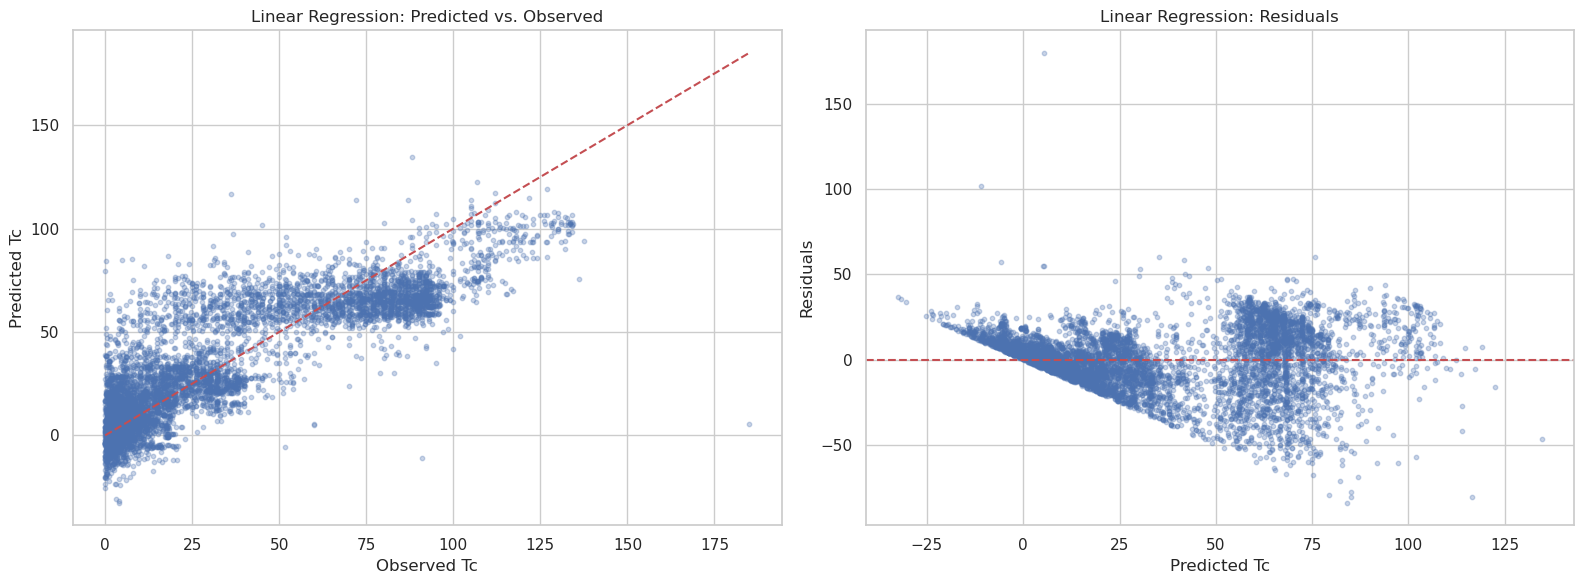

Random Forest:


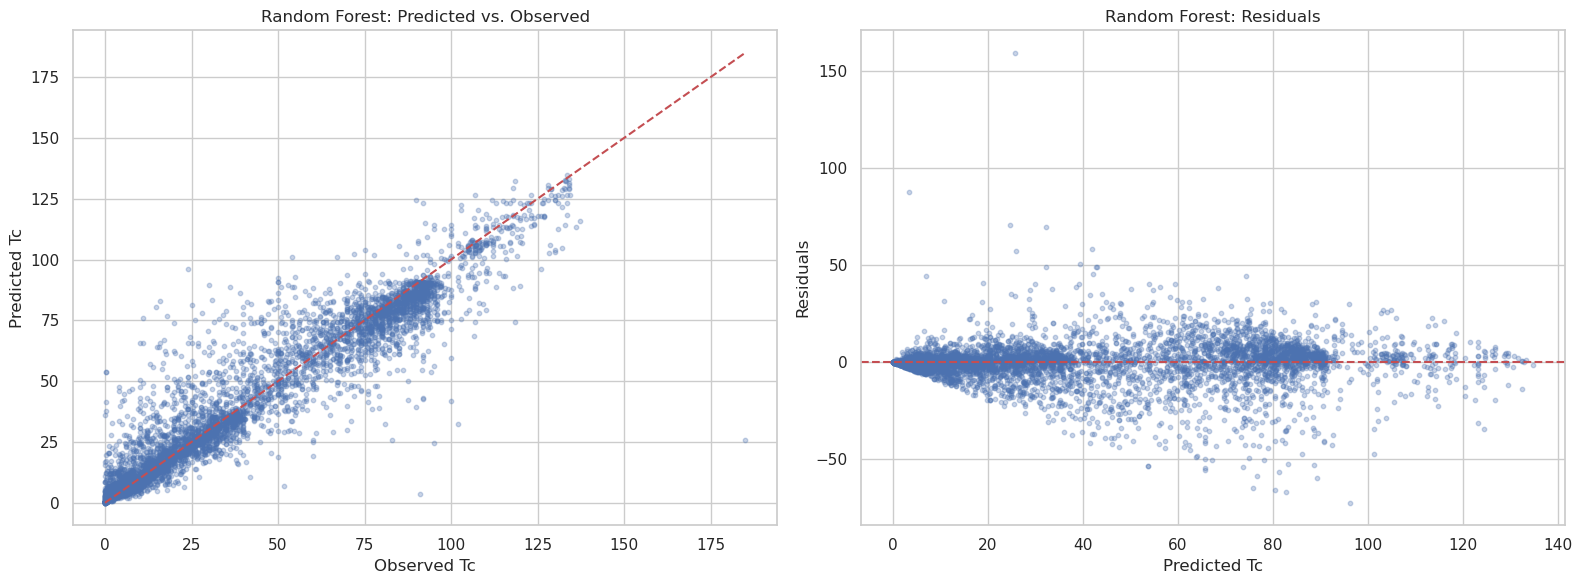

In [4]:
print("Linear Regression:")
lr_pipeline.plot_results()

print("Random Forest:")
rf_pipeline.plot_results()

### Model Comparison: Visual Analysis

#### Linear Regression (Baseline)
The predicted-vs-observed plot reveals systematic deviations from the 
diagonal. Below 25 K (observed), predictions are consistently too high, 
indicating that the linear model struggles with conventional 
superconductors. Between 50–80 K observed, a broad horizontal band 
appears, showing that the model produces similar predictions across 
a wide range of true temperatures — effectively smearing the 
non-linear transition zone. The residual plot exhibits a clear 
descending linear pattern, confirming systematic bias rather than 
random noise.

#### Random Forest (Main Model)
The predicted-vs-observed scatter closely follows the diagonal 
reference line across the entire T_c range (0–185 K). Residuals are 
approximately symmetrically distributed around zero with no 
discernible pattern, indicating that the model captures the 
underlying physical relationships without systematic over- or 
underprediction.

#### Conclusion
The visual comparison confirms the quantitative metrics: the Random 
Forest model successfully captures the non-linear, multi-modal 
relationships between elemental properties and critical temperature, 
while the linear baseline suffers from systematic bias inherent to 
its modeling assumptions.

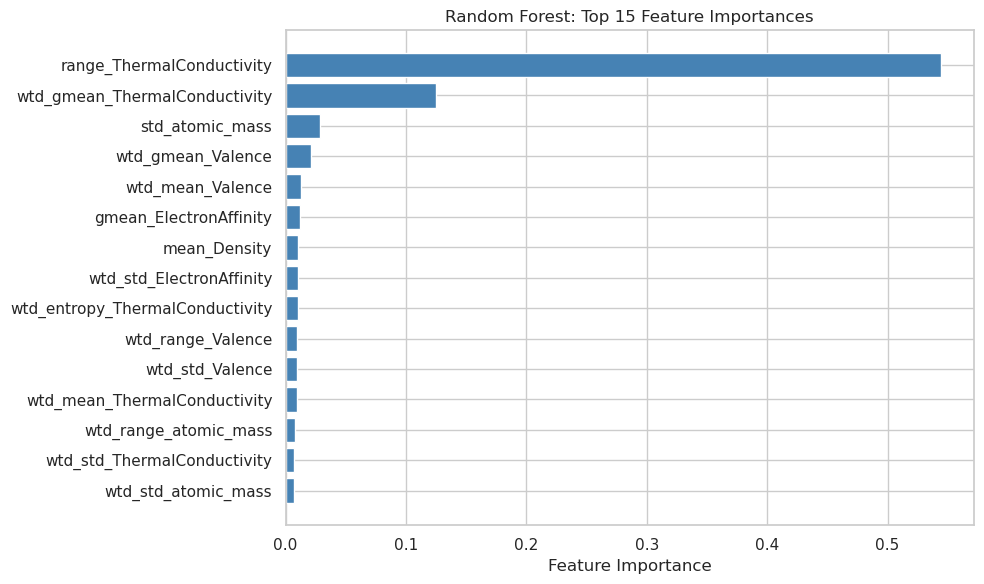

In [8]:
# extract feature importances from Random Forest
importances = rf_pipeline.model.model.feature_importances_
feature_names = df.drop(columns=["critical_temp"]).columns


feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top15 = feat_imp.head(15)
ax.barh(range(len(top15)), top15["importance"].values, color="steelblue")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Feature Importance: Random Forest vs. Linear Correlation

The top feature identified by the Random Forest is 
`range_ThermalConductivity` with an importance of 0.55 - more than 
four times higher than the second-ranked feature 
(`wtd_mean_ThermalConductivity`, 0.12). This contrasts with the EDA, 
where the top 10 features showed similar correlation magnitudes 
(~0.6-0.72). 

This discrepancy highlights a fundamental difference between linear 
correlation and tree-based feature importance:

- **Correlation coefficients** measure linear associations only. 
  Features with similar correlations suggest they vary proportionally 
  with T_c across the entire dataset.

- **Random Forest importance** captures non-linear relationships and 
  interaction effects. The dominance of `range_ThermalConductivity` 
  suggests that the *variation* in thermal conductivity among elements 
  carries more predictive power than their absolute values or means.

Interestingly, both methods agree on the qualitative hierarchy: thermal 
conductivity features dominate the importance ranking, followed by 
atomic radius and valence. This convergence reinforces the central 
role of electron-phonon coupling mechanisms in determining critical 
temperatures.

In [10]:
df_material = pd.read_csv("../data/raw/unique_m.csv")
df_material["is_cuprate"] = (df_material["Cu"] > 0) & (df_material["O"] > 0)
df_material["is_iron_pnictide"] = (df_material["Fe"] > 0) & ((df_material["As"] > 0) | (df_material["Se"] > 0))

# Add to df_train (same ordering of indices!)
df_merged = df.copy()  
for col in ["is_cuprate", "is_iron_pnictide"]:
    df_merged[col] = df_material[col].values

df_merged.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp,is_cuprate,is_iron_pnictide
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0,True,False
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0,True,False
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0,True,False
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0,True,False
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0,True,False


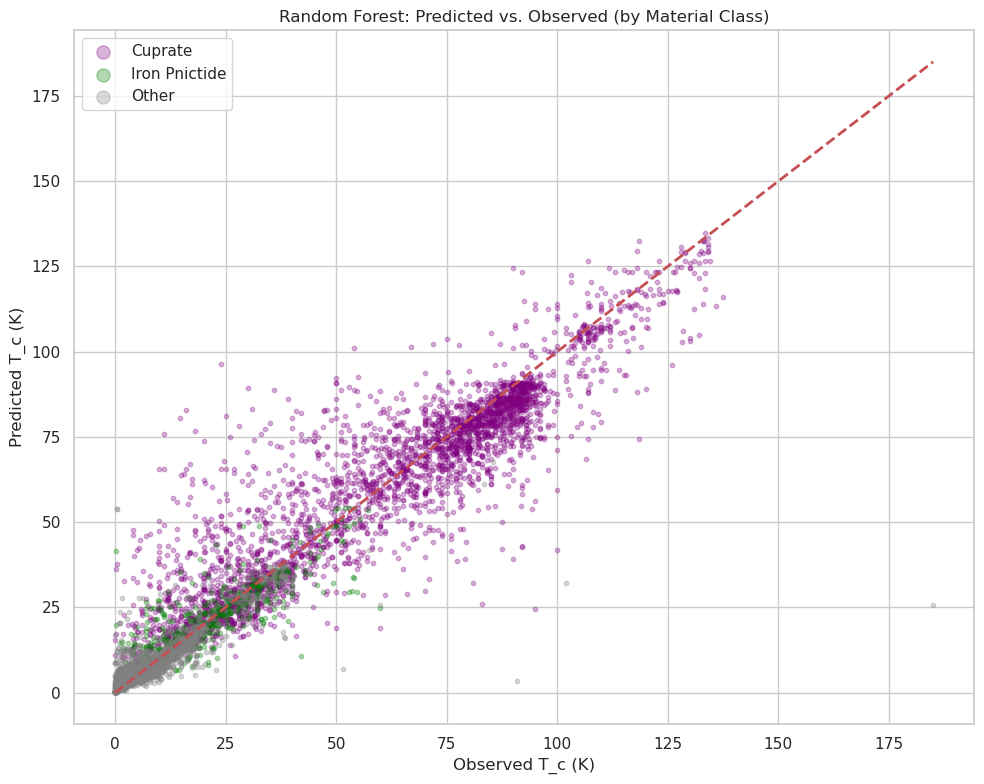

In [14]:
# get material classes of test-data
test_indices = rf_pipeline.y_test.index

# class as string for plot
def get_class_label(row):
    if row["is_cuprate"]:
        return "Cuprate"
    elif row["is_iron_pnictide"]:
        return "Iron Pnictide"
    else:
        return "Other"

test_classes = df_merged.loc[test_indices, ["is_cuprate", "is_iron_pnictide"]].apply(get_class_label, axis=1)

# Predicted vs. Observed with color coding
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"Cuprate": "purple", "Iron Pnictide": "green", "Other": "gray"}

for cls_name, color in colors.items():
    mask = test_classes == cls_name
    ax.scatter(
        rf_pipeline.y_test[mask],
        rf_pipeline.y_pred[mask],
        alpha=0.3, s=10, c=color, label=cls_name
    )

# Diagonal reference
lim = [rf_pipeline.y_test.min(), rf_pipeline.y_test.max()]
ax.plot(lim, lim, "r--", linewidth=2)

ax.set_xlabel("Observed T_c (K)")
ax.set_ylabel("Predicted T_c (K)")
ax.set_title("Random Forest: Predicted vs. Observed (by Material Class)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### Predicted vs. Observed by Material Class

The colored scatter plot reveals class-specific model performance:

- **Cuprates (purple)**: Show the widest scatter, reflecting the 
  heterogeneity of this family. Simple Cu-O compounds and complex 
  multi-layer cuprates (e.g., YBCO, BSCCO) share similar elemental 
  features but differ drastically in T_c due to layer count, doping 
  level, and crystal structure — information not captured by the 
  81 compositional features.

- **Iron Pnictides (green)**: Display moderate scatter, consistent 
  with the diversity of structure types (1111, 122, 11) within this 
  family. Similar elemental composition but different crystal 
  structures lead to varying T_c that the model cannot fully resolve.

- **Conventional Superconductors (gray)**: Show the tightest clustering 
  along the diagonal, indicating reliable predictions for the majority 
  of materials in this class. However, a small number of extreme 
  outliers are visible — likely unconventional superconductors 
  (e.g., MgB₂, T_c ≈ 39 K) that are grouped into "Other" by 
  composition-based classification but possess unexpectedly high T_c 
  values. The model systematically underpredicts these rare cases, 
  as they represent a fundamentally different pairing mechanism 
  not reflected in the compositional feat